<a href="https://colab.research.google.com/github/Mauricioortiga/Engenharia-de-Prompt-e-Aplicacoes-em-IA/blob/main/Programa%C3%A7%C3%A3oAssistidaPorAIAula07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aula 07 - Miniprojeto **

Nome: Kadidja Valéria

Disciplina: Engenharia de Prompt e Aplicações em IA

In [ ]:
#Soma de Lista
numeros = [1, 2, 3, 4, 5, 6]
soma = sum(numeros)
print(f"A soma total é: {soma}")

A soma total é: 21


In [ ]:
#Número Primo
import math

def eh_primo(numero):
    if numero < 2:
        return False
    for i in range (2, int(math.sqrt(numero)) + 1):
      if numero % i == 0:
        return False
    return True

In [ ]:
#Inversão de String
def inverte_texto(texto):
  return texto[::-1]

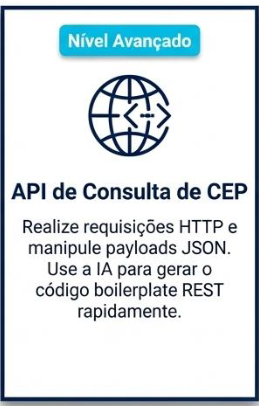

In [ ]:
import requests
import json

def consultar_cep(cep):
    """
    Consulta um CEP utilizando a API ViaCEP.
    Retorna os dados do endereço em formato JSON.
    """
    # A API ViaCEP geralmente não precisa de autenticação para consultas simples.
    # Formato da URL da API ViaCEP:
    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        # Faz a requisição HTTP GET para a API
        response = requests.get(url)
        response.raise_for_status()  # Levanta um HTTPError para respostas de erro (4xx ou 5xx)

        # Tenta decodificar a resposta JSON
        data = response.json()

        # ViaCEP retorna um dicionário com uma chave 'erro' se o CEP for inválido
        if 'erro' in data and data['erro']:
            print(f"Erro: CEP {cep} não encontrado ou inválido.")
            return None
        else:
            return data

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP: {http_err} - Status Code: {response.status_code}")
        return None
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de Conexão: {conn_err}")
        return None
    except requests.exceptions.Timeout as timeout_err:
        print(f"Erro de Timeout: {timeout_err}")
        return None
    except requests.exceptions.RequestException as req_err:
        print(f"Erro inesperado na requisição: {req_err}")
        return None
    except json.JSONDecodeError:
        print("Erro ao decodificar a resposta JSON.")
        print(f"Resposta da API (texto): {response.text}")
        return None

# --- Exemplo de uso ---

# Consulta um CEP válido
cep_valido = "01001000"  # São Paulo, SP
dados_cep = consultar_cep(cep_valido)

if dados_cep:
    print(f"\nDados do CEP {cep_valido}:")
    print(json.dumps(dados_cep, indent=4, ensure_ascii=False)) # Imprime JSON formatado
    print(f"Endereço: {dados_cep.get('logradouro')}, {dados_cep.get('bairro')} - {dados_cep.get('localidade')}/{dados_cep.get('uf')}")

# Consulta um CEP inválido
cep_invalido = "99999999"
dados_cep_invalido = consultar_cep(cep_invalido)

if not dados_cep_invalido:
    print(f"\nComo esperado, nenhum dado retornado para o CEP inválido {cep_invalido}.")


# --- Boilerplate REST Client (mais genérico) ---

class RESTClient:
    def __init__(self, base_url):
        self.base_url = base_url

    def _make_request(self, method, endpoint, params=None, data=None, json_data=None, headers=None):
        url = f"{self.base_url}/{endpoint}"
        try:
            response = requests.request(method, url, params=params, data=data, json=json_data, headers=headers)
            response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
            return response.json() # Assume JSON response
        except requests.exceptions.HTTPError as http_err:
            print(f"HTTP error occurred: {http_err} - {response.status_code} - {response.text}")
        except requests.exceptions.ConnectionError as conn_err:
            print(f"Connection error occurred: {conn_err}")
        except requests.exceptions.Timeout as timeout_err:
            print(f"Timeout error occurred: {timeout_err}")
        except requests.exceptions.RequestException as e:
            print(f"An unexpected error occurred: {e}")
        except json.JSONDecodeError:
            print(f"Failed to decode JSON from response: {response.text}")
        return None

    def get(self, endpoint, params=None, headers=None):
        return self._make_request('GET', endpoint, params=params, headers=headers)

    def post(self, endpoint, data=None, json_data=None, headers=None):
        return self._make_request('POST', endpoint, data=data, json_data=json_data, headers=headers)

    def put(self, endpoint, data=None, json_data=None, headers=None):
        return self._make_request('PUT', endpoint, data=data, json_data=json_data, headers=headers)

    def delete(self, endpoint, headers=None):
        return self._make_request('DELETE', endpoint, headers=headers)

# --- Exemplo de uso do cliente REST genérico com ViaCEP ---
print("\n--- Exemplo de uso do cliente REST genérico com ViaCEP ---")
cep_api_base_url = "https://viacep.com.br/ws"
cep_client = RESTClient(cep_api_base_url)

# Endpoint para consulta de CEP é "{cep}/json/"
# Vamos consultar o mesmo CEP válido
cep_para_cliente = "01001000"
endpoint = f"{cep_para_cliente}/json/"
dados_via_cliente = cep_client.get(endpoint)

if dados_via_cliente:
    print(f"\nDados do CEP {cep_para_cliente} (via RESTClient genérico):")
    print(json.dumps(dados_via_cliente, indent=4, ensure_ascii=False))
else:
    print(f"Falha ao obter dados para o CEP {cep_para_cliente} via RESTClient genérico.")





Dados do CEP 01001000:
{
    "cep": "01001-000",
    "logradouro": "Praça da Sé",
    "complemento": "lado ímpar",
    "unidade": "",
    "bairro": "Sé",
    "localidade": "São Paulo",
    "uf": "SP",
    "estado": "São Paulo",
    "regiao": "Sudeste",
    "ibge": "3550308",
    "gia": "1004",
    "ddd": "11",
    "siafi": "7107"
}
Endereço: Praça da Sé, Sé - São Paulo/SP
Erro: CEP 99999999 não encontrado ou inválido.

Como esperado, nenhum dado retornado para o CEP inválido 99999999.

--- Exemplo de uso do cliente REST genérico com ViaCEP ---

Dados do CEP 01001000 (via RESTClient genérico):
{
    "cep": "01001-000",
    "logradouro": "Praça da Sé",
    "complemento": "lado ímpar",
    "unidade": "",
    "bairro": "Sé",
    "localidade": "São Paulo",
    "uf": "SP",
    "estado": "São Paulo",
    "regiao": "Sudeste",
    "ibge": "3550308",
    "gia": "1004",
    "ddd": "11",
    "siafi": "7107"
}
